# 01 – Veri Keşfi (EDA)
### AMR Prediction | DRIAMS-A 2018

## 1. DRIAMS-A 2018 Verilerini Yükle

In [1]:
import sys
sys.path.append("..")  # src/ modüllerine erişim

import pandas as pd
from pathlib import Path

DRIAMS_ROOT = Path("../data/driams")

# DRIAMS-A 2018 etiket dosyasını yükle
path = DRIAMS_ROOT / "DRIAMS-A" / "id" / "2018" / "2018_clean.csv"
df = pd.read_csv(path, low_memory=False)

print(f"Toplam örnek sayısı : {len(df):,}")
print(f"Toplam sütun sayısı : {df.shape[1]}")
df[["code", "species"]].head()

Toplam örnek sayısı : 30,069
Toplam sütun sayısı : 87


,code,species
0,18e02f6b-4b84-4344-9b7a-2a9cc2b5e2b6_MALDI1,Pseudomonas aeruginosa
1,e9544679-3f9d-43f6-8ce3-aac053980742_MALDI1,Candida glabrata
2,bfcad108-864f-4b37-83f3-d7dc94265213_MALDI1,Klebsiella pneumoniae
3,c649f842-5926-4bb3-8aef-d411db4241f4_MALDI1,Staphylococcus capitis
4,69eca649-ec26-4f9d-9f9a-d42aa5b9ec0f_MALDI1,Escherichia coli


## 2. Sınıf Dağılımı – Antibiyotiklere Göre R/S Oranları

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Meta sütunları çıkar, sadece antibiyotik sütunlarını al
meta_cols = {"code", "species", "laboratory_species", "Unnamed: 0", "Unnamed: 0.1"}
antibiotic_cols = [c for c in df.columns if c not in meta_cols]

# Her antibiyotik için R ve S sayısını hesapla
summary = []
for ab in antibiotic_cols:
    counts = df[ab].value_counts()
    r = counts.get("R", 0)
    s = counts.get("S", 0)
    total = r + s
    if total >= 100:  # Az örnekli antibiyotikleri atla
        summary.append({
            "antibiyotik": ab,
            "S": s,
            "R": r,
            "toplam": total,
            "R_oranı": round(r / total * 100, 1)
        })

summary_df = pd.DataFrame(summary).sort_values("toplam", ascending=False).reset_index(drop=True)
print(f"100+ etiketli antibiyotik sayısı: {len(summary_df)}")
summary_df

100+ etiketli antibiyotik sayısı: 46


,antibiyotik,S,R,toplam,R_oranı
0,Ciprofloxacin,6450,1644,8094,20.3
1,Meropenem,6787,1169,7956,14.7
2,Imipenem,6283,1417,7700,18.4
3,Piperacillin-Tazobactam,6115,1583,7698,20.6
4,Cefepime,6247,1317,7564,17.4
5,Ampicillin-Amoxicillin,1440,5926,7366,80.5
6,Cotrimoxazole,5907,1269,7176,17.7
7,Ceftriaxone,5302,1738,7040,24.7
8,Amoxicillin-Clavulanic acid,4191,2667,6858,38.9
9,Levofloxacin,4711,993,5704,17.4


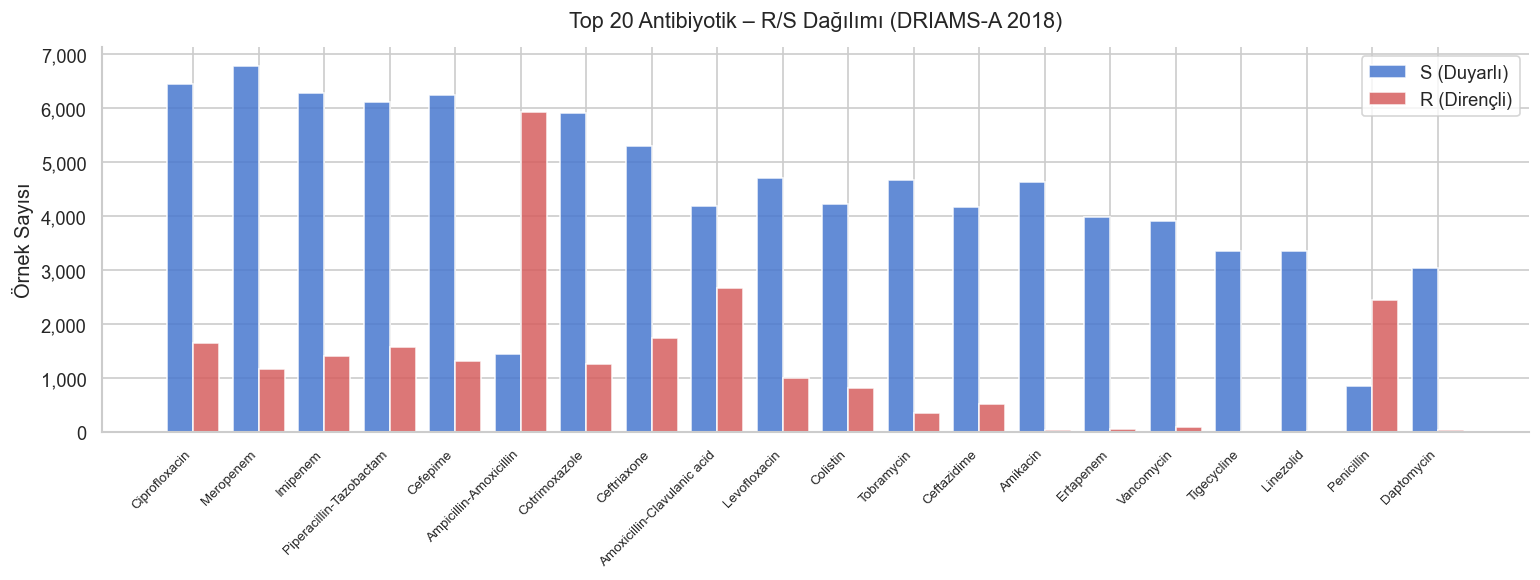

Grafik kaydedildi: outputs/figures/rs_dagilimi_top20.png


In [3]:
# En çok örneği olan 20 antibiyotiği görselleştir
top20 = summary_df.head(20).copy()
x = np.arange(len(top20))
w = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, top20["S"], width=w, label="S (Duyarlı)",  color="#4878CF", alpha=0.85)
ax.bar(x + w/2, top20["R"], width=w, label="R (Dirençli)", color="#D65F5F", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top20["antibiyotik"], rotation=45, ha="right", fontsize=8)
ax.set_title("Top 20 Antibiyotik – R/S Dağılımı (DRIAMS-A 2018)", fontsize=13, pad=12)
ax.set_ylabel("Örnek Sayısı")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/rs_dagilimi_top20.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/rs_dagilimi_top20.png")

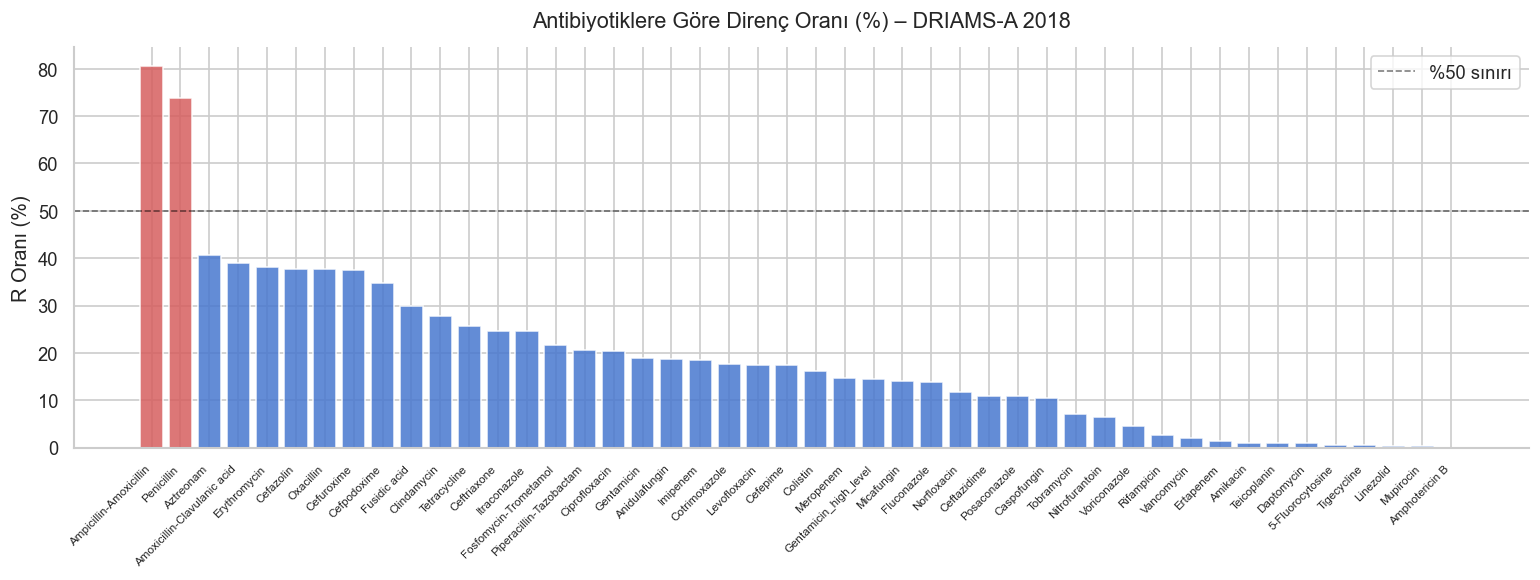

Grafik kaydedildi: outputs/figures/r_orani_antibiyotik.png


In [4]:
# R oranına göre sırala ve görselleştir
fig, ax = plt.subplots(figsize=(13, 5))
sorted_df = summary_df.sort_values("R_oranı", ascending=False)

colors = ["#D65F5F" if r >= 50 else "#4878CF" for r in sorted_df["R_oranı"]]
bars = ax.bar(range(len(sorted_df)), sorted_df["R_oranı"], color=colors, alpha=0.85, edgecolor="white")

ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5, label="%50 sınırı")
ax.set_xticks(range(len(sorted_df)))
ax.set_xticklabels(sorted_df["antibiyotik"], rotation=45, ha="right", fontsize=7)
ax.set_title("Antibiyotiklere Göre Direnç Oranı (%) – DRIAMS-A 2018", fontsize=13, pad=12)
ax.set_ylabel("R Oranı (%)")
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/r_orani_antibiyotik.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/r_orani_antibiyotik.png")

## 3. Spektrum Görselleştirmesi – Ortalama R vs S Spektrumu

Ciprofloxacin için R ve S etiketli örneklerin ortalama spektrumlarını karşılaştırıyoruz.
Model bu iki spektrum arasındaki farkı öğrenmeye çalışıyor.

In [5]:
from src.data.load_driams import load_driams

print("Veri yükleniyor, lütfen bekleyin...")
X, y, meta = load_driams("DRIAMS-A", "2018", "Ciprofloxacin")

print(f"\n--- Veri Özeti ---")
print(f"Toplam örnek : {len(y)}")
print(f"R (dirençli) : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"S (duyarlı)  : {(1-y).sum()} ({(1-y.mean())*100:.1f}%)")
print(f"X shape      : {X.shape}")

Veri yükleniyor, lütfen bekleyin...



--- Veri Özeti ---
Toplam örnek : 8094
R (dirençli) : 1644 (20.3%)
S (duyarlı)  : 6450 (79.7%)
X shape      : (8094, 6000)


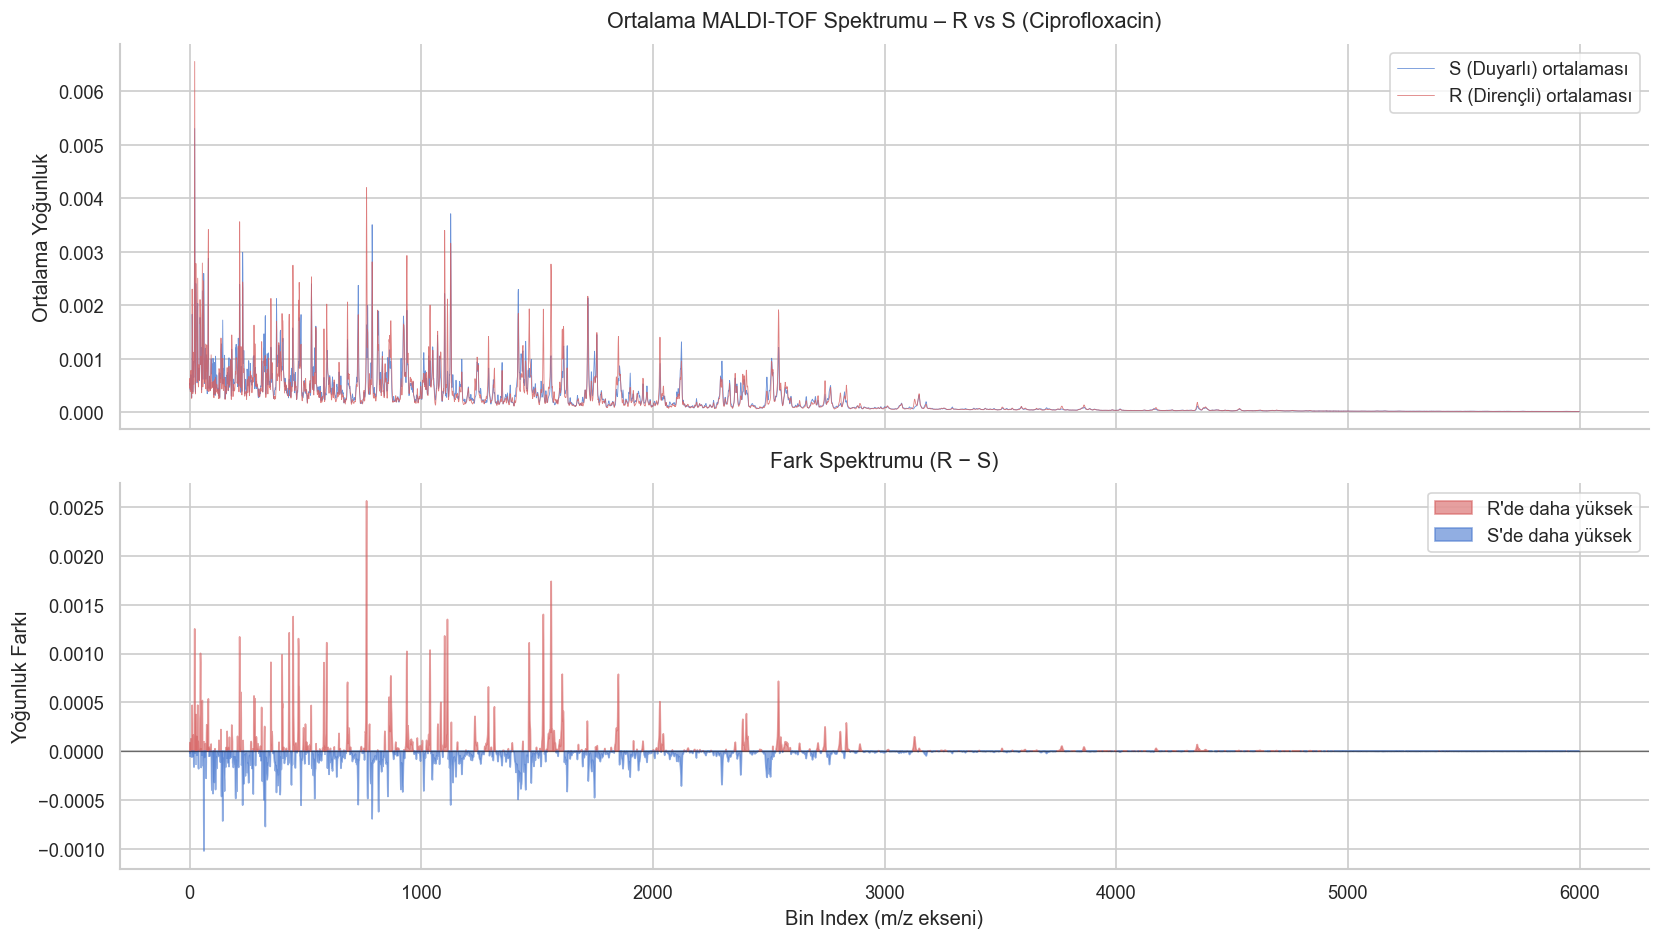

Grafik kaydedildi: outputs/figures/spektrum_R_vs_S.png


In [6]:
# R ve S örneklerinin ortalama spektrumunu hesapla
mean_R = X[y == 1].mean(axis=0)
mean_S = X[y == 0].mean(axis=0)
diff   = mean_R - mean_S  # pozitif → R'de daha yüksek

bin_index = np.arange(6000)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Üst grafik: Ortalama spektrumlar ---
axes[0].plot(bin_index, mean_S, color="#4878CF", alpha=0.8, linewidth=0.5, label="S (Duyarlı) ortalaması")
axes[0].plot(bin_index, mean_R, color="#D65F5F", alpha=0.8, linewidth=0.5, label="R (Dirençli) ortalaması")
axes[0].set_title("Ortalama MALDI-TOF Spektrumu – R vs S (Ciprofloxacin)", fontsize=13, pad=10)
axes[0].set_ylabel("Ortalama Yoğunluk")
axes[0].legend(frameon=True)
sns.despine(ax=axes[0])

# --- Alt grafik: Fark (R - S) ---
axes[1].fill_between(bin_index, diff, 0,
                     where=(diff > 0), color="#D65F5F", alpha=0.6, label="R'de daha yüksek")
axes[1].fill_between(bin_index, diff, 0,
                     where=(diff < 0), color="#4878CF", alpha=0.6, label="S'de daha yüksek")
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_title("Fark Spektrumu (R − S)", fontsize=13, pad=10)
axes[1].set_xlabel("Bin Index (m/z ekseni)")
axes[1].set_ylabel("Yoğunluk Farkı")
axes[1].legend(frameon=True)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig("../outputs/figures/spektrum_R_vs_S.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/spektrum_R_vs_S.png")

In [7]:
# En büyük farkın olduğu bin bölgelerini bul (modelin en çok dikkat etmesi gereken yerler)
import numpy as np

top_n = 10
top_bins = np.argsort(np.abs(diff))[::-1][:top_n]

print("En büyük R vs S farkının olduğu bin bölgeleri (modelin önem verdiği yerler):")
print(f"{'Bin':>6}  {'Fark':>10}  {'Yön'}")
print("-" * 30)
for b in top_bins:
    yon = "R daha yüksek" if diff[b] > 0 else "S daha yüksek"
    print(f"{b:>6}  {diff[b]:>10.6f}  {yon}")

En büyük R vs S farkının olduğu bin bölgeleri (modelin önem verdiği yerler):
   Bin        Fark  Yön
------------------------------
   764    0.002564  R daha yüksek
   763    0.002035  R daha yüksek
   765    0.001782  R daha yüksek
  1561    0.001741  R daha yüksek
  1560    0.001712  R daha yüksek
  1527    0.001401  R daha yüksek
   447    0.001379  R daha yüksek
  1113    0.001350  R daha yüksek
  1562    0.001260  R daha yüksek
    22    0.001253  R daha yüksek


## 4. Eksik Veri Analizi – Antibiyotiklere Göre Örnek Sayısı

Her antibiyotik sütununda kaç etiketli (R/S) örnek var, kaçı eksik (NaN)?  
Bu analiz hangi antibiyotiklerle model eğitilebileceğini belirlememize yardımcı olur.

In [8]:
# Eksik veri analizi
meta_cols = {"code", "species", "laboratory_species", "Unnamed: 0", "Unnamed: 0.1"}
antibiotic_cols = [c for c in df.columns if c not in meta_cols]

total = len(df)
missing_data = []
for ab in antibiotic_cols:
    nan_count = df[ab].isna().sum()
    labeled = total - nan_count
    r = (df[ab] == "R").sum()
    s = (df[ab] == "S").sum()
    missing_data.append({
        "antibiyotik": ab,
        "etiketli": labeled,
        "eksik": nan_count,
        "eksik_oran": round(nan_count / total * 100, 1),
        "R": r,
        "S": s,
    })

missing_df = pd.DataFrame(missing_data).sort_values("etiketli", ascending=False).reset_index(drop=True)

print(f"Toplam örnek sayısı : {total:,}")
print(f"Antibiyotik sayısı  : {len(antibiotic_cols)}")
print(f"\nEtiketli örnek sayısı >= 100 olan : {(missing_df['etiketli'] >= 100).sum()}")
print(f"Hiç etiketi olmayan (tümü NaN)    : {(missing_df['etiketli'] == 0).sum()}")
print()
missing_df

Toplam örnek sayısı : 30,069
Antibiyotik sayısı  : 82

Etiketli örnek sayısı >= 100 olan : 82
Hiç etiketi olmayan (tümü NaN)    : 0



,antibiyotik,etiketli,eksik,eksik_oran,R,S
0,Penicillin,9997,20072,66.8,2437,862
1,Penicillin_with_endokarditis,9997,20072,66.8,12,43
2,Teicoplanin,9997,20072,66.8,22,2091
3,Strepomycin_high_level,9997,20072,66.8,0,0
4,Amoxicillin-Clavulanic acid_uncomplicated_HWI,9997,20072,66.8,11,13
...,...,...,...,...,...,...
77,Gentamicin_high_level,9997,20072,66.8,26,155
78,Ampicillin-Sulbactam,9997,20072,66.8,0,0
79,Ceftarolin,9997,20072,66.8,2,1
80,Gentamicin,9997,20072,66.8,523,2239


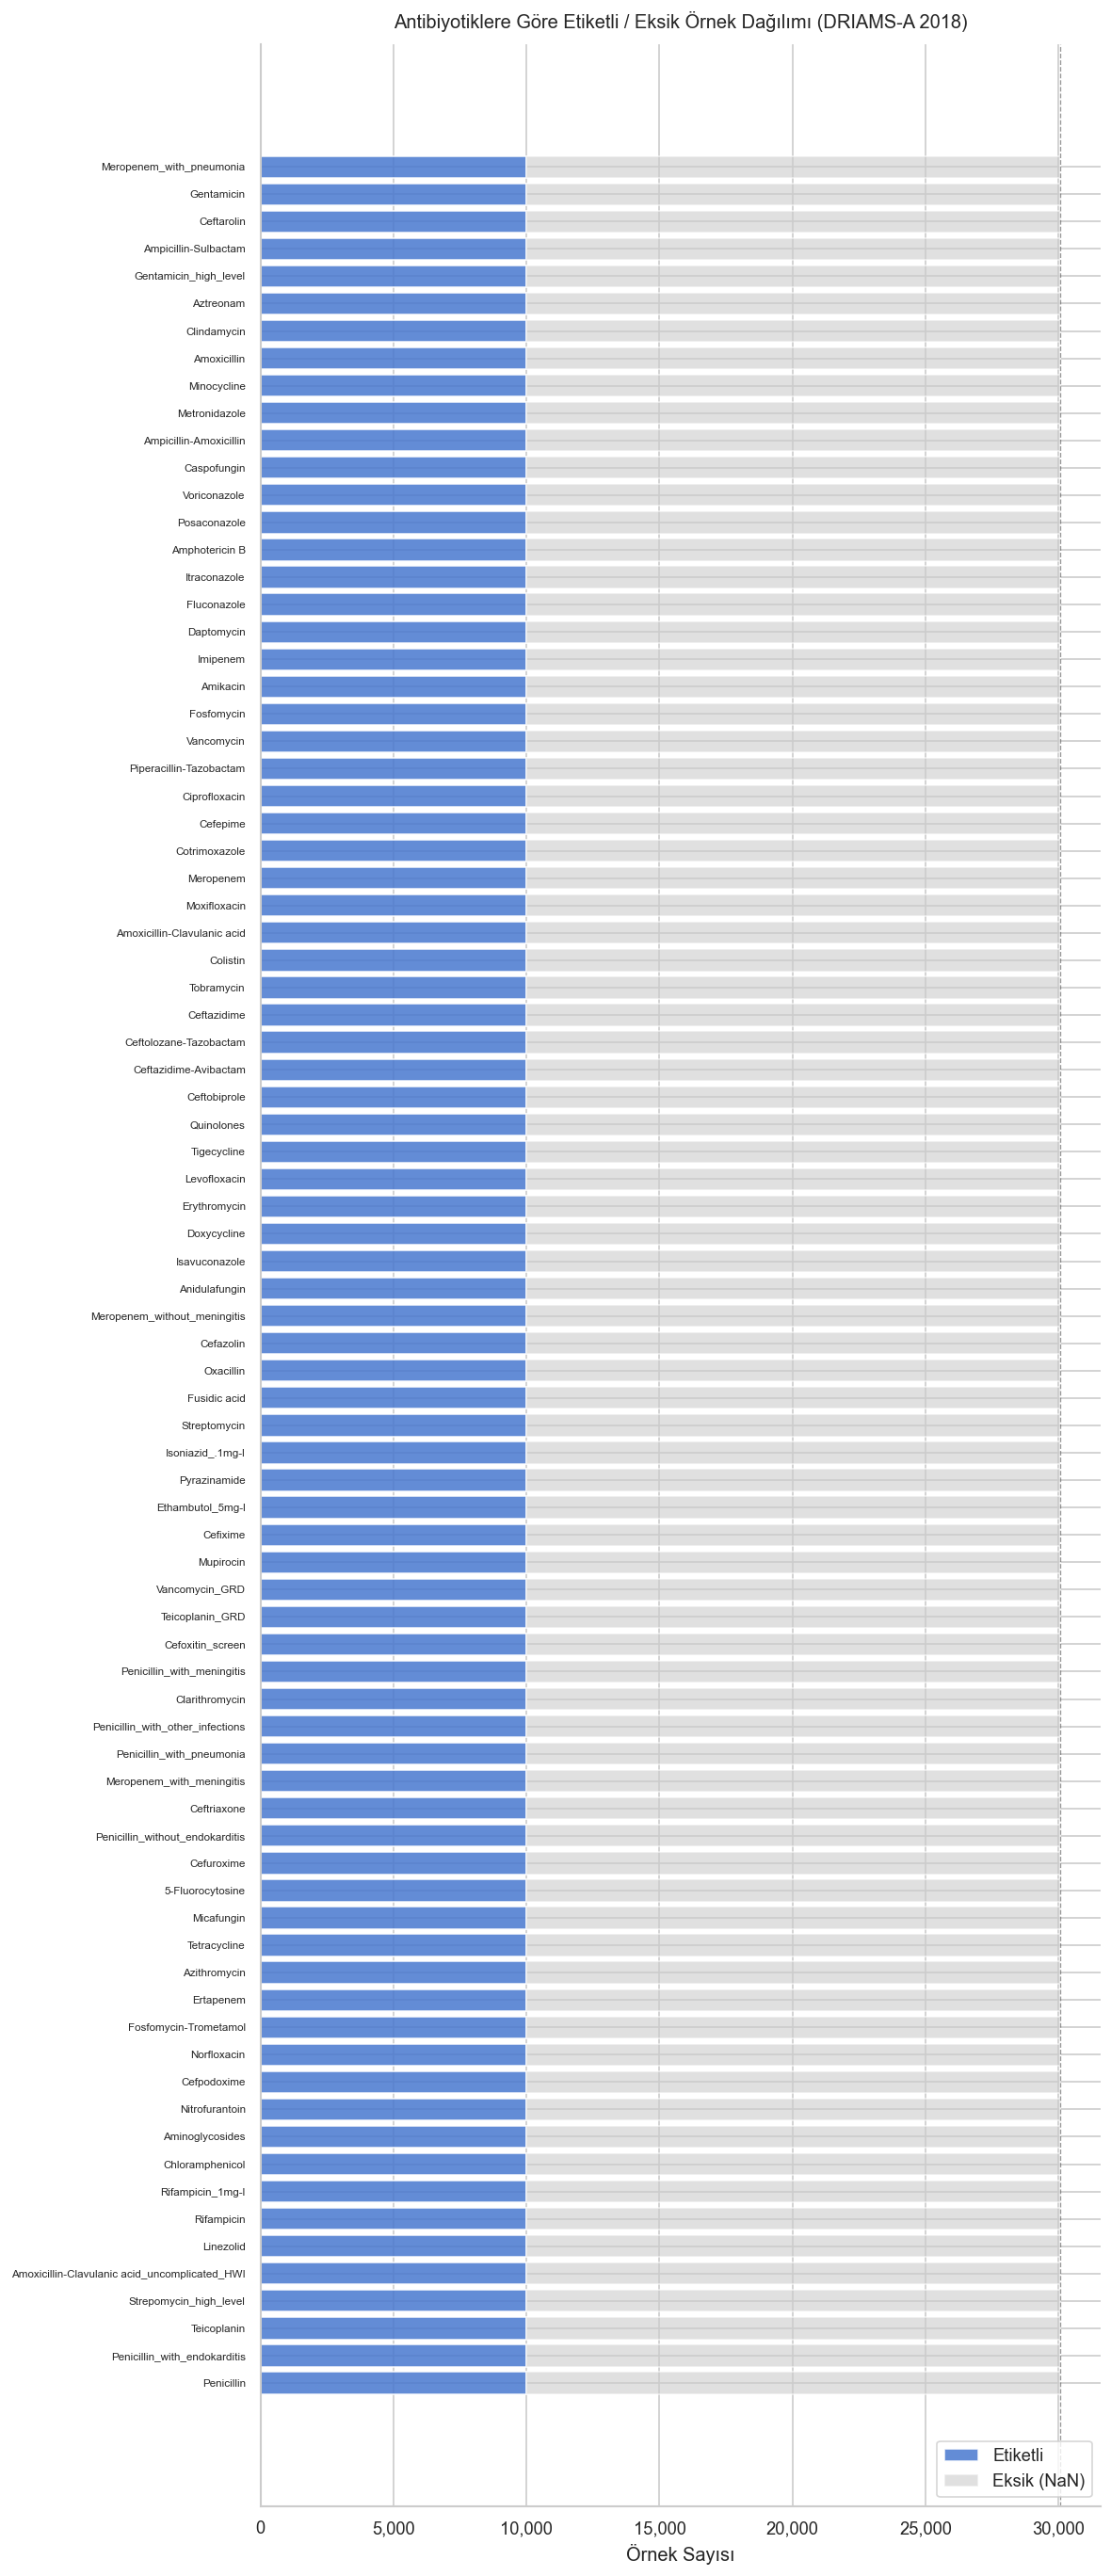

Grafik kaydedildi: outputs/figures/eksik_veri_dagilimi.png


In [9]:
# Görselleştirme 1: Antibiyotiklere göre etiketli vs eksik örnek sayısı (yatay bar)
top_ab = missing_df[missing_df["etiketli"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, max(6, len(top_ab) * 0.28)))
y_pos = np.arange(len(top_ab))

ax.barh(y_pos, top_ab["etiketli"], color="#4878CF", alpha=0.85, label="Etiketli")
ax.barh(y_pos, top_ab["eksik"],    left=top_ab["etiketli"], color="#CCCCCC", alpha=0.6, label="Eksik (NaN)")

ax.set_yticks(y_pos)
ax.set_yticklabels(top_ab["antibiyotik"], fontsize=7)
ax.set_xlabel("Örnek Sayısı")
ax.set_title("Antibiyotiklere Göre Etiketli / Eksik Örnek Dağılımı (DRIAMS-A 2018)", fontsize=12, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.axvline(total, color="black", linewidth=0.8, linestyle="--", alpha=0.4)
ax.legend(loc="lower right")
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/eksik_veri_dagilimi.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/eksik_veri_dagilimi.png")

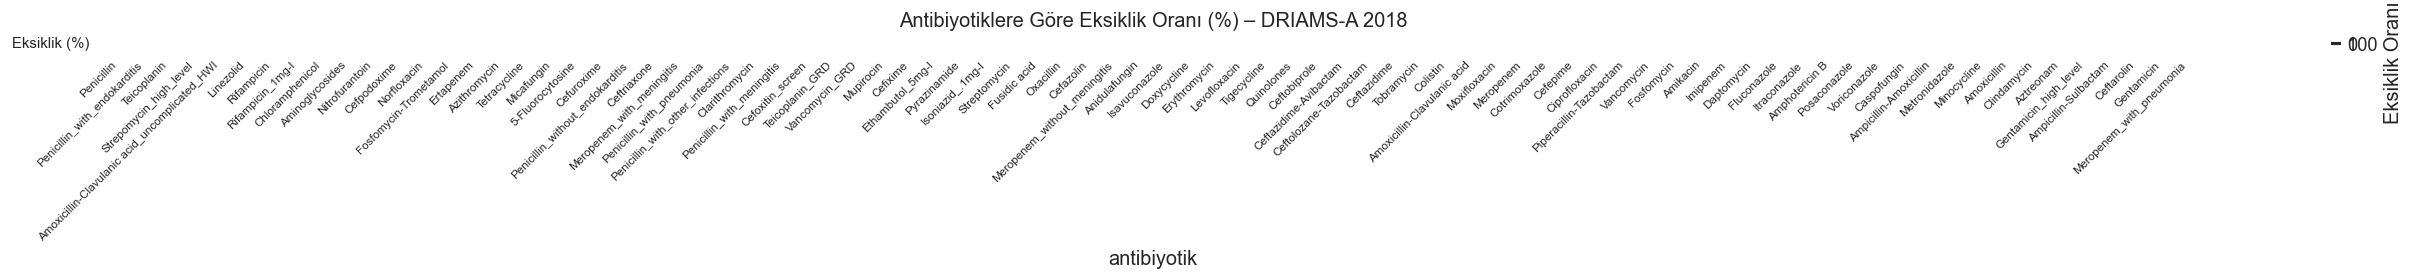

Grafik kaydedildi: outputs/figures/eksiklik_heatmap.png


In [10]:
# Görselleştirme 2: Eksiklik oranı ısı haritası (missingness heatmap)
# Her antibiyotik için eksiklik oranını renk skalasıyla göster
heat_data = missing_df.set_index("antibiyotik")[["eksik_oran"]].T

fig, ax = plt.subplots(figsize=(max(12, len(missing_df) * 0.28), 2.5))
sns.heatmap(
    heat_data,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Eksiklik Oranı (%)"},
    vmin=0, vmax=100
)
ax.set_yticklabels(["Eksiklik (%)"], rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_title("Antibiyotiklere Göre Eksiklik Oranı (%) – DRIAMS-A 2018", fontsize=12, pad=10)
plt.tight_layout()
plt.savefig("../outputs/figures/eksiklik_heatmap.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/eksiklik_heatmap.png")

In [11]:
# Özet: Eksiklik eşiğine göre kullanılabilir antibiyotik sayıları
thresholds = [50, 100, 200, 500, 1000]
print("Minimum etiketli örnek eşiğine göre kullanılabilir antibiyotik sayısı:")
print(f"{'Eşik':>8}  {'Antibiyotik Sayısı':>20}")
print("-" * 32)
for t in thresholds:
    n = (missing_df["etiketli"] >= t).sum()
    print(f"{t:>8,}  {n:>20}")

# Eksikliği %70'ten fazla olan antibiyotikler (model için uygun değil)
cok_eksik = missing_df[missing_df["eksik_oran"] > 70]
print(f"\n%70'ten fazla eksik veriye sahip antibiyotikler ({len(cok_eksik)} adet):")
print(cok_eksik[["antibiyotik", "etiketli", "eksik", "eksik_oran"]].to_string(index=False))

Minimum etiketli örnek eşiğine göre kullanılabilir antibiyotik sayısı:
    Eşik    Antibiyotik Sayısı
--------------------------------
      50                    82
     100                    82
     200                    82
     500                    82
   1,000                    82

%70'ten fazla eksik veriye sahip antibiyotikler (0 adet):
Empty DataFrame
Columns: [antibiyotik, etiketli, eksik, eksik_oran]
Index: []


## 5. Sparsity Analizi – Spektrum Yoğunluk Dağılımı

MALDI-TOF spektrumları genellikle sparse'tır: çoğu bin sıfıra yakın.  
Sparsity oranı hem preprocessing kararını (VarianceThreshold eşiği) hem model seçimini etkiler.

Ortalama sıfır oranı (örnek bazlı) : 0.083
Medyan  sıfır oranı (örnek bazlı)  : 0.015
Sıfır olmayan bin oranı (bin bazlı): 1.000
Tüm örneklerde sıfır olan bin sayısı: 0
%95+ örnekte sıfır olan bin sayısı  : 0


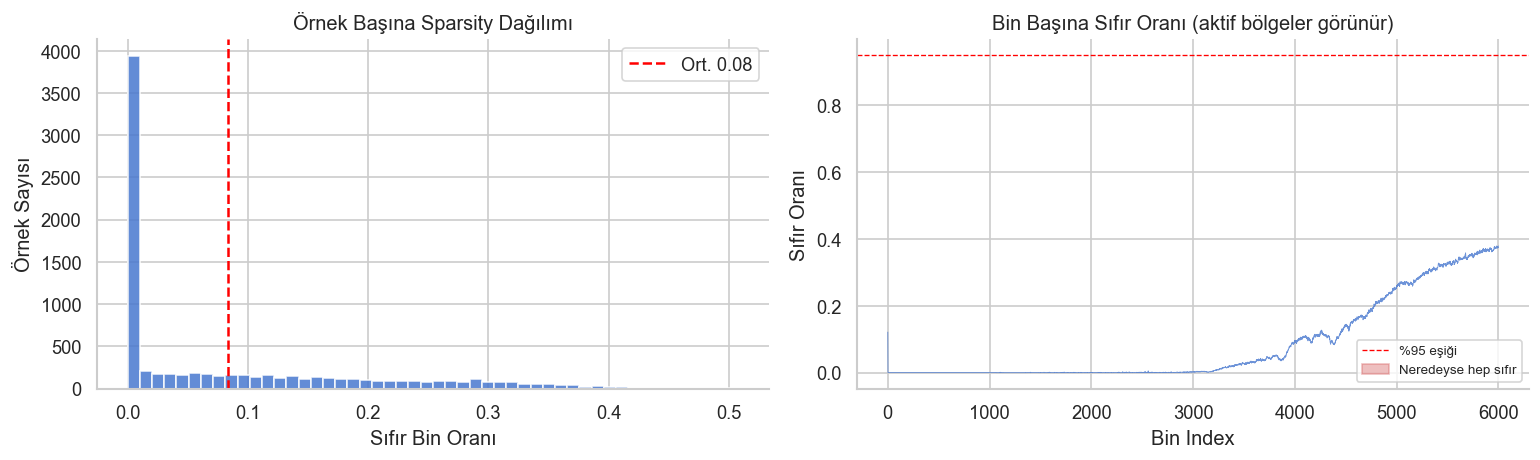

Grafik kaydedildi: outputs/figures/sparsity_analizi.png


In [12]:
# Sparsity: her örnekte kaç bin sıfır?
zero_ratio_per_sample = (X == 0).mean(axis=1)  # her satır için sıfır oranı
zero_ratio_per_bin    = (X == 0).mean(axis=0)  # her bin için sıfır oranı

print(f"Ortalama sıfır oranı (örnek bazlı) : {zero_ratio_per_sample.mean():.3f}")
print(f"Medyan  sıfır oranı (örnek bazlı)  : {np.median(zero_ratio_per_sample):.3f}")
print(f"Sıfır olmayan bin oranı (bin bazlı): {(zero_ratio_per_bin < 1.0).mean():.3f}")
print(f"Tüm örneklerde sıfır olan bin sayısı: {(zero_ratio_per_bin == 1.0).sum()}")
print(f"%95+ örnekte sıfır olan bin sayısı  : {(zero_ratio_per_bin >= 0.95).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sol: örnek başına sıfır oranı dağılımı
axes[0].hist(zero_ratio_per_sample, bins=50, color="#4878CF", alpha=0.85, edgecolor="white")
axes[0].axvline(zero_ratio_per_sample.mean(), color="red", linestyle="--", label=f"Ort. {zero_ratio_per_sample.mean():.2f}")
axes[0].set_xlabel("Sıfır Bin Oranı")
axes[0].set_ylabel("Örnek Sayısı")
axes[0].set_title("Örnek Başına Sparsity Dağılımı")
axes[0].legend()

# Sağ: bin başına sıfır oranı (hangi bölgeler hep sıfır?)
axes[1].plot(np.arange(6000), zero_ratio_per_bin, linewidth=0.5, color="#4878CF", alpha=0.8)
axes[1].axhline(0.95, color="red", linestyle="--", linewidth=0.8, label="%95 eşiği")
axes[1].fill_between(np.arange(6000), zero_ratio_per_bin, 0.95,
                     where=(zero_ratio_per_bin >= 0.95), color="#D65F5F", alpha=0.4, label="Neredeyse hep sıfır")
axes[1].set_xlabel("Bin Index")
axes[1].set_ylabel("Sıfır Oranı")
axes[1].set_title("Bin Başına Sıfır Oranı (aktif bölgeler görünür)")
axes[1].legend(fontsize=8)

sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/sparsity_analizi.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/sparsity_analizi.png")

## 6. Species (Bakteri Türü) Dağılımı

Hangi bakteriler en çok ölçülmüş? Veri seti belirli türlere mi baskın?  
Model türler arasında genelleme yapabiliyor mu, yoksa dominant türe mi overfit ediyor?

Toplam unique tür sayısı : 113
Top 5 türün veri oranı   : %31.6


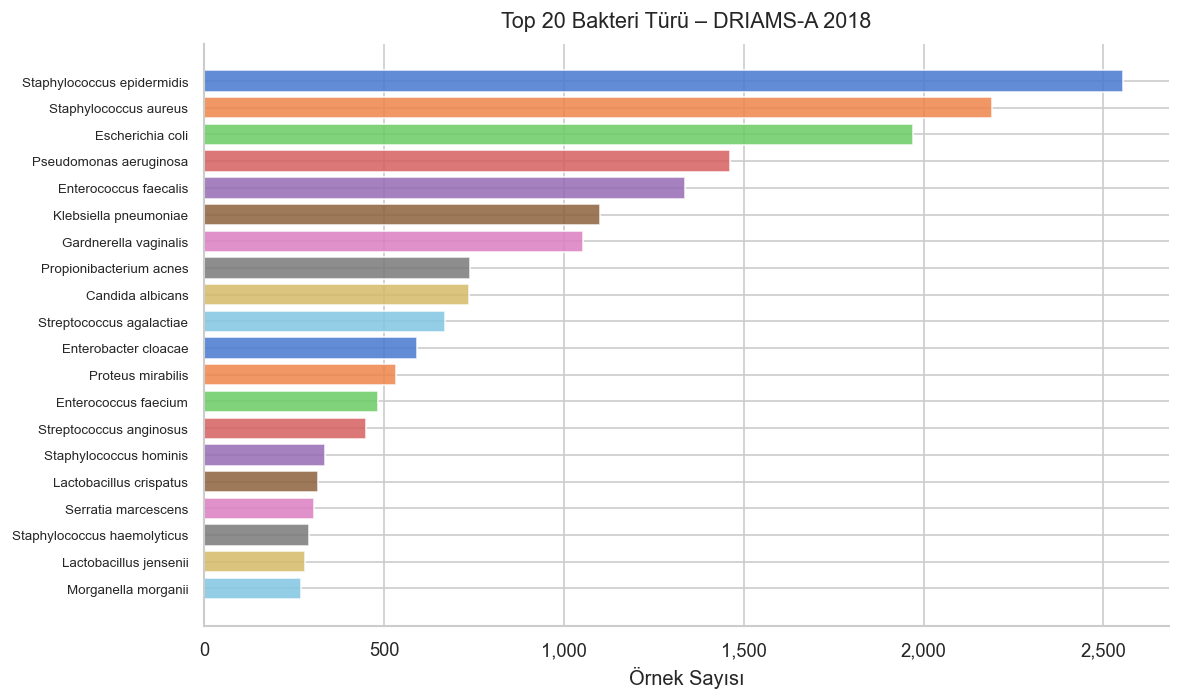

Grafik kaydedildi: outputs/figures/species_dagilimi.png


In [13]:
# En yaygın 20 bakteri türü
species_counts = df["species"].value_counts()
top20_species  = species_counts.head(20)

print(f"Toplam unique tür sayısı : {species_counts.nunique()}")
print(f"Top 5 türün veri oranı   : %{top20_species.head(5).sum() / len(df) * 100:.1f}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("muted", len(top20_species))
ax.barh(range(len(top20_species)), top20_species.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_yticks(range(len(top20_species)))
ax.set_yticklabels(top20_species.index[::-1], fontsize=8)
ax.set_xlabel("Örnek Sayısı")
ax.set_title("Top 20 Bakteri Türü – DRIAMS-A 2018", fontsize=13, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
sns.despine()
plt.tight_layout()
plt.savefig("../outputs/figures/species_dagilimi.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/species_dagilimi.png")

Ciprofloxacin – tür bazlı direnç oranı (n≥30, 22 tür):
                              R_oranı     n
species                                    
Staphylococcus haemolyticus  0.547170    53
Staphylococcus epidermidis   0.518647  1153
Campylobacter jejuni         0.375000    56
Escherichia coli             0.262259  1346
Pseudomonas aeruginosa       0.168831   924
Proteus mirabilis            0.161290   279
MIX!Klebsiella pneumoniae    0.156250    32
Klebsiella pneumoniae        0.147757   758
Staphylococcus aureus        0.131670  1162
Staphylococcus hominis       0.121212   165
Staphylococcus capitis       0.098039   102
Serratia marcescens          0.079646   226
Morganella morganii          0.073684    95
Enterobacter cloacae         0.049180   366
Citrobacter freundii         0.039604   101


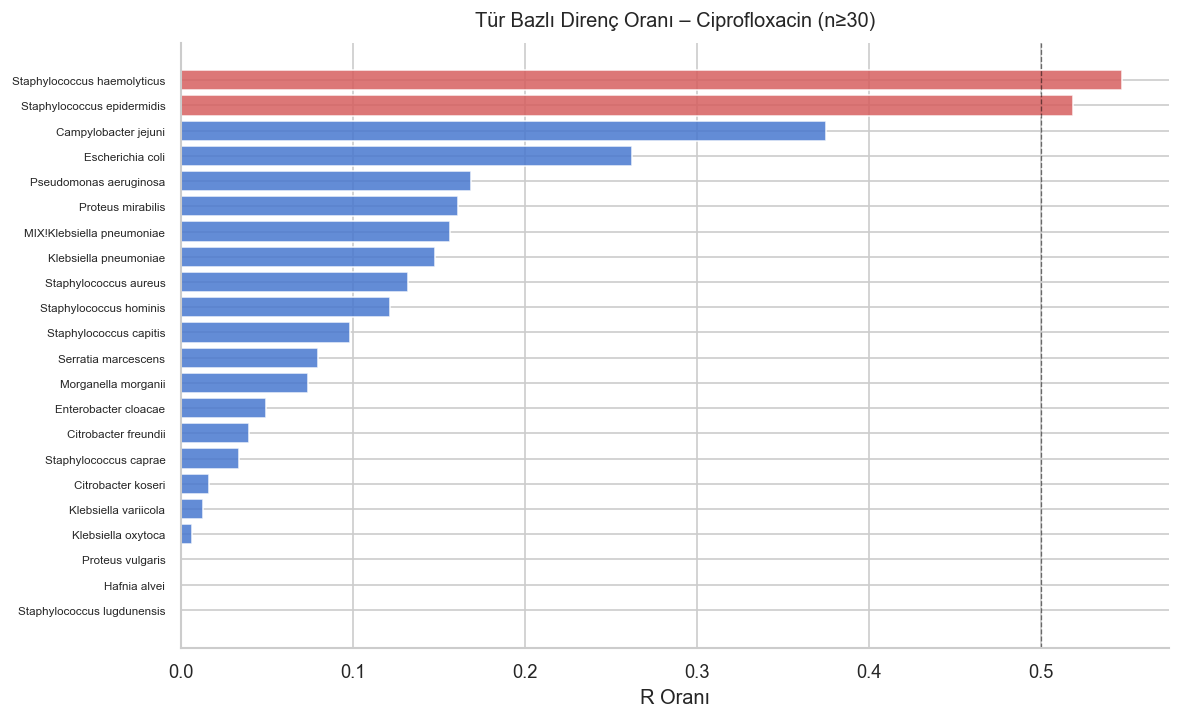

Grafik kaydedildi: outputs/figures/species_R_orani_Ciprofloxacin.png


In [14]:
# Ciprofloxacin için: türe göre R oranı (en az 30 örneği olan türler)
ab = "Ciprofloxacin"
cip_df = df[df[ab].isin(["R", "S"])][["species", ab]].copy()
cip_df["resistant"] = (cip_df[ab] == "R").astype(int)

species_ab = (
    cip_df.groupby("species")["resistant"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "R_oranı", "count": "n"})
    .query("n >= 30")
    .sort_values("R_oranı", ascending=False)
)

print(f"Ciprofloxacin – tür bazlı direnç oranı (n≥30, {len(species_ab)} tür):")
print(species_ab.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, max(5, len(species_ab) * 0.28)))
colors = ["#D65F5F" if r >= 0.5 else "#4878CF" for r in species_ab["R_oranı"]]
ax.barh(range(len(species_ab)), species_ab["R_oranı"].values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_yticks(range(len(species_ab)))
ax.set_yticklabels(species_ab.index[::-1], fontsize=7)
ax.set_xlabel("R Oranı")
ax.set_title(f"Tür Bazlı Direnç Oranı – {ab} (n≥30)", fontsize=12, pad=10)
sns.despine()
plt.tight_layout()
plt.savefig(f"../outputs/figures/species_R_orani_{ab}.png", dpi=150)
plt.show()
print(f"Grafik kaydedildi: outputs/figures/species_R_orani_{ab}.png")

## 7. Antibiyotikler Arası Korelasyon (Co-resistance)

Bazı antibiyotiklere direnç birlikte görülür (cross-resistance).  
Bu korelasyonu bilmek; hangi antibiyotiklerin birbirinden bağımsız bilgi taşıdığını gösterir.

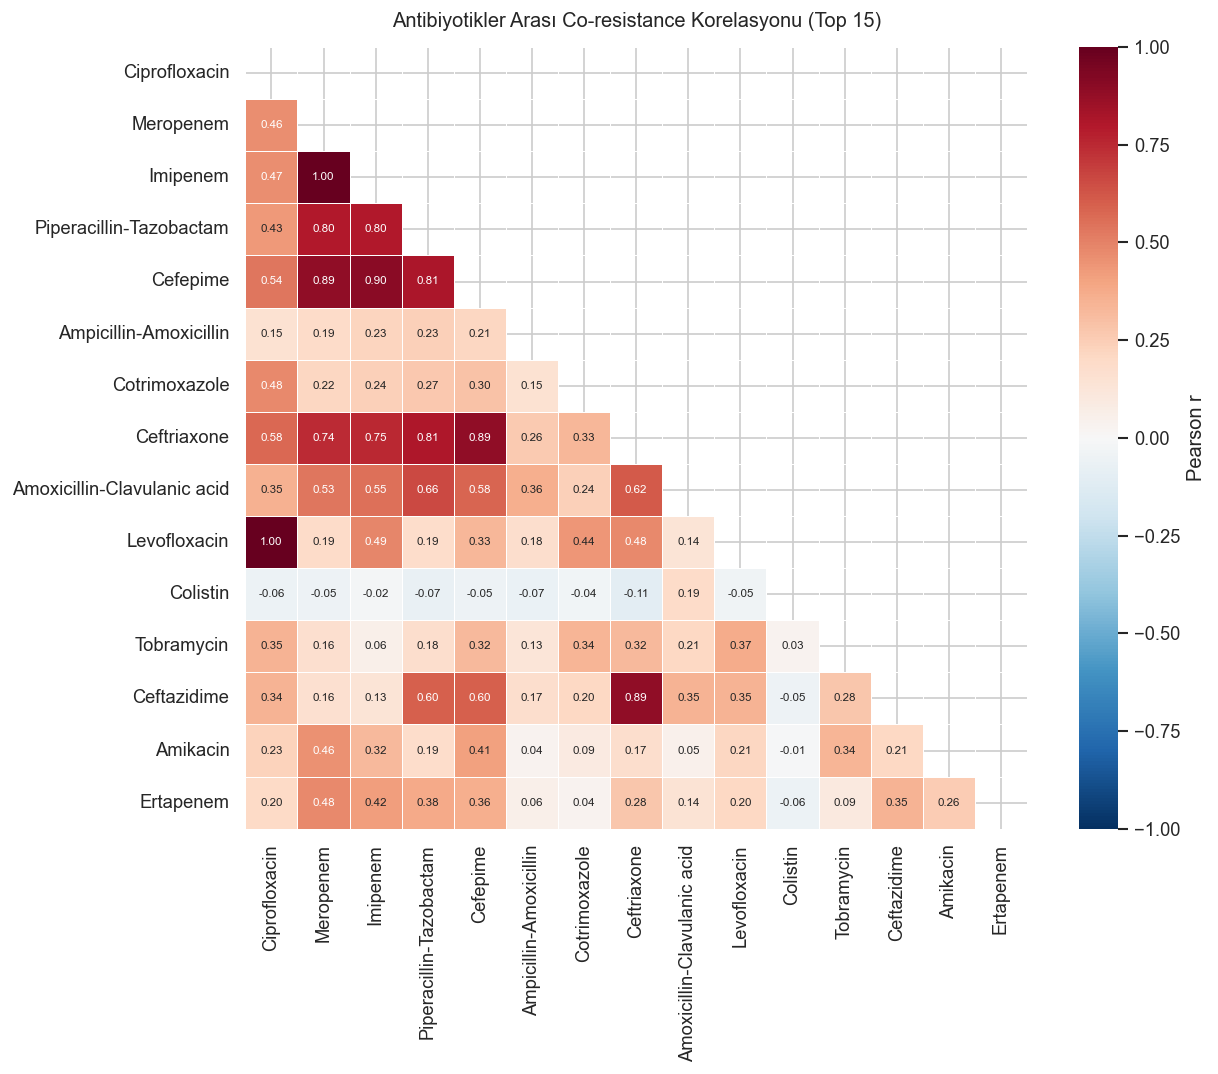

Grafik kaydedildi: outputs/figures/coresistance_korelasyon.png


In [15]:
# En fazla örneği olan 15 antibiyotik için co-resistance korelasyon matrisi
top15_abs = summary_df.head(15)["antibiyotik"].tolist()

# Sadece R/S değerlerini tut, diğerlerini NaN yap; sonra binary'e çevir
binary_df = df[top15_abs].apply(lambda col: col.map({"R": 1, "S": 0}))

corr = binary_df.corr(method="pearson", min_periods=50)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    linewidths=0.5, square=True,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Antibiyotikler Arası Co-resistance Korelasyonu (Top 15)", fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("../outputs/figures/coresistance_korelasyon.png", dpi=150)
plt.show()
print("Grafik kaydedildi: outputs/figures/coresistance_korelasyon.png")